# Pessimistic Rewards Curb Reward Hacking in Molecular RL
*Penalising oracle uncertainty (R = μ − λσ) to keep a de novo agent inside its QSAR model's domain*

## Abstract

A reinforcement-learning generator is only as trustworthy as the reward that guides it. When that reward is a QSAR model, the agent tends to exploit the model's blind spots and produces molecules with high predicted activity that lie outside the model's applicability domain. This notebook tests a direct countermeasure on the EGFR oracle: replace the point prediction by a pessimistic reward, R = μ − λσ, where μ and σ are the mean and standard deviation of a bootstrap ensemble of ten XGBoost models. A first check confirms that σ acts as a domain detector: known EGFR inhibitors have low σ (gefitinib 0.11, erlotinib 0.14), while unrelated or exotic molecules have a larger spread. Sweeping λ from 0 to 10 over three seeds, higher λ pulls the agent's top molecules back into the training domain (mean maximum Tanimoto rising from 0.36 to 0.49) and makes them more drug-like (QED from 0.21 to 0.33 at λ = 2), two quantities the reward never optimises directly. The gain is largest around λ ≈ 2, where reliability improves at essentially no cost in predicted activity; larger λ overshoots and collapses both activity and diversity. The drop in σ itself is partly circular, since σ is what the reward penalises, so the applicability-domain and QED shifts are the meaningful evidence. The activities remain QSAR predictions on a single target, and the uncertainty is an ensemble estimate, not a calibrated interval.

## Methods

**Oracle and uncertainty.** EGFR activity data were retrieved from ChEMBL (IC50, binding assays, values in nM converted to pIC50 and aggregated per compound), about 10,000 molecules. Ten XGBoost regressors were trained on bootstrap resamples of this set, each on the same 2048-bit ECFP4 plus seven-descriptor featurisation used throughout. For a molecule, μ is the mean and σ the standard deviation of the ten predictions. Bootstrap resampling makes the models disagree where data are sparse, so σ rises outside the training domain.

**Pessimistic reward.** The reward returned to the agent was R = μ − λσ, mapped to [0,1] by a fixed sigmoid (5 to 9 pIC50) and used as the single scoring component with REINVENT's diversity filter disabled, so that λ was the only lever. λ was swept over {0, 2, 5, 10}; λ = 0 recovers the ordinary, exploitable reward.

**RL runs and metrics.** Each (λ, seed) run used REINVENT 4 in staged-learning mode on CPU, 150 steps of batch size 64, DAP strategy with sigma 128 and learning rate 1e-4. Three seeds were run per λ. For each run, the 100 top-scoring molecules were characterised by their mean μ and σ, their mean maximum Tanimoto to 2000 sampled training molecules (an applicability-domain proxy), and their mean QED. Results are reported as mean and standard deviation across seeds.

In [17]:
from rdkit import RDLogger
RDLogger.DisableLog("rdApp.*")

In [18]:
import pandas as pd
import numpy as np
from chembl_webresource_client.new_client import new_client

targets = {
    "hERG": "CHEMBL240",       
    "EGFR": "CHEMBL203", 
}

def get_target_data(chembl_id):
    res = new_client.activity.filter(
        target_chembl_id=chembl_id, standard_type="IC50",
        relation="=", assay_type="B",
    ).only(["molecule_chembl_id", "canonical_smiles", "standard_value", "standard_units"])
    df = pd.DataFrame(res)
    if len(df) == 0:
        return pd.DataFrame(columns=["smiles", "pIC50"])
    df = df[df["standard_units"] == "nM"]
    df["standard_value"] = pd.to_numeric(df["standard_value"], errors="coerce")
    df = df.dropna(subset=["standard_value", "canonical_smiles"])
    df = df[(df["standard_value"] >= 1) & (df["standard_value"] <= 1e7)]
    df["pIC50"] = 9 - np.log10(df["standard_value"])
    df = (df.groupby("molecule_chembl_id")
            .agg(smiles=("canonical_smiles", "first"), pIC50=("pIC50", "median"))
            .reset_index(drop=True))
    return df

data = {}
for name, cid in targets.items():
    df_t = get_target_data(cid)
    print(name, "| molecules:", len(df_t))
    if len(df_t) > 200:
        data[name] = df_t
print("kept targets:", list(data.keys()))

REPO = "/mnt/c/Users/coure/Projects/cheminformatics"

data["EGFR"].to_csv(f"{REPO}/models/egfr_ic50.csv", index=False)
data["hERG"].to_csv(f"{REPO}/models/herg_ic50.csv", index=False)

hERG | molecules: 8348
EGFR | molecules: 10128
kept targets: ['hERG', 'EGFR']


In [19]:
import numpy as np
from rdkit import Chem
from rdkit.Chem import Descriptors, rdMolDescriptors, AllChem

def featurize_one(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    fp = np.array(AllChem.GetMorganFingerprintAsBitVect(mol, 2, 2048))
    desc = [Descriptors.MolLogP(mol), Descriptors.MolWt(mol), Descriptors.NumHDonors(mol),
            Descriptors.NumHAcceptors(mol), Descriptors.TPSA(mol),
            rdMolDescriptors.CalcNumAromaticRings(mol), Descriptors.NumRotatableBonds(mol)]
    return np.hstack([fp, desc]).astype(np.float32)

In [20]:
from xgboost import XGBRegressor
import joblib

df_egfr = data["EGFR"]
feats = [featurize_one(s) for s in df_egfr["smiles"]]
mask  = np.array([f is not None for f in feats])
X = np.vstack([f for f in feats if f is not None])
y = df_egfr["pIC50"].values[mask]

N_MODELS = 10
rng = np.random.default_rng(0)
ensemble = []
for k in range(N_MODELS):
    idx = rng.integers(0, len(y), len(y))                  # rééchantillon bootstrap
    m = XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=6, random_state=k)
    m.fit(X[idx], y[idx])
    ensemble.append(m)

joblib.dump(ensemble, f"{REPO}/models/egfr_ensemble.joblib")   # dump APRÈS la boucle
print("ensemble entraîné :", len(ensemble), "modèles")

ensemble entraîné : 10 modèles


In [21]:
def predict_mu_sigma(smiles):
    x = featurize_one(smiles)
    if x is None:
        return np.nan, np.nan
    preds = np.array([mdl.predict(x.reshape(1, -1))[0] for mdl in ensemble])
    return float(preds.mean()), float(preds.std())

## Results and Discussion

In [22]:
panel = [
    ("gefitinib (EGFR inhibitor)", "COc1cc2ncnc(Nc3ccc(F)c(Cl)c3)c2cc1OCCCN1CCOCC1"),
    ("erlotinib (EGFR inhibitor)", "COCCOc1cc2ncnc(Nc3cccc(C#C)c3)c2cc1OCCOC"),
    ("aspirin (unrelated drug)",   "CC(=O)Oc1ccccc1C(=O)O"),
    ("caffeine (unrelated)",       "Cn1cnc2c1c(=O)n(C)c(=O)n2C"),
    ("glucose (out-of-domain)",    "OCC1OC(O)C(O)C(O)C1O"),
    ("long alkane (out-of-domain)","CCCCCCCCCCCCCCCCCC"),
]
for label, s in panel:
    mu, sig = predict_mu_sigma(s)
    print(f"{label:30s} | mu = {mu:5.2f} | sigma = {sig:.2f}")

gefitinib (EGFR inhibitor)     | mu =  7.47 | sigma = 0.11
erlotinib (EGFR inhibitor)     | mu =  7.52 | sigma = 0.14
aspirin (unrelated drug)       | mu =  4.40 | sigma = 0.43
caffeine (unrelated)           | mu =  5.46 | sigma = 0.19
glucose (out-of-domain)        | mu =  4.78 | sigma = 0.36
long alkane (out-of-domain)    | mu =  4.90 | sigma = 0.21


The ensemble spread separates known chemistry from unfamiliar chemistry, as required. The two marketed EGFR inhibitors sit at the lowest σ (0.11 and 0.14) together with the highest μ, whereas unrelated drugs and clearly out-of-domain molecules such as glucose or a long alkane carry a larger spread. The separation is real but modest in absolute terms (σ roughly 0.1 to 0.4 across the panel), which already tells us that λ will need to be of order a few units to move the reward meaningfully. This is the precondition for the whole approach: if σ did not track the domain, penalising it would be pointless.

In [23]:
import joblib, numpy as np, pandas as pd
import matplotlib.pyplot as plt
from rdkit import Chem, DataStructs
from rdkit.Chem import Descriptors, rdMolDescriptors, AllChem, QED

REPO = "/mnt/c/Users/coure/Projects/cheminformatics"
ensemble = joblib.load(f"{REPO}/models/egfr_ensemble.joblib")
df_egfr = pd.read_csv(f"{REPO}/models/egfr_ic50.csv")

def featurize_one(s):
    m = Chem.MolFromSmiles(s)
    if m is None: return None
    fp = np.array(AllChem.GetMorganFingerprintAsBitVect(m, 2, 2048))
    d = [Descriptors.MolLogP(m), Descriptors.MolWt(m), Descriptors.NumHDonors(m),
         Descriptors.NumHAcceptors(m), Descriptors.TPSA(m),
         rdMolDescriptors.CalcNumAromaticRings(m), Descriptors.NumRotatableBonds(m)]
    return np.hstack([fp, d]).astype(np.float32)

def predict_mu_sigma(s):
    x = featurize_one(s)
    if x is None: return np.nan, np.nan
    p = np.array([mdl.predict(x.reshape(1, -1))[0] for mdl in ensemble])
    return float(p.mean()), float(p.std())

REF_FPS = [AllChem.GetMorganFingerprintAsBitVect(m, 2, 2048)
           for s in np.random.default_rng(0).choice(df_egfr["smiles"].values, 2000, replace=False)
           if (m := Chem.MolFromSmiles(s)) is not None]

def max_tani(s):
    m = Chem.MolFromSmiles(s)
    if m is None: return np.nan
    return max(DataStructs.BulkTanimotoSimilarity(AllChem.GetMorganFingerprintAsBitVect(m, 2, 2048), REF_FPS))

In [24]:
lambdas = [0, 2, 5,10]
rows = []
for L in lambdas:
    d = pd.read_csv(f"{REPO}/rl_runs/egfr_pessimism/egfr_pess_l{L}_1.csv")
    top = d.sort_values("Score", ascending=False)["SMILES"].drop_duplicates().head(100).tolist()
    mus, sigs = zip(*[predict_mu_sigma(s) for s in top])
    rows.append({
        "lambda": L,
        "mean_mu": np.nanmean(mus),
        "mean_sigma": np.nanmean(sigs),
        "mean_tanimoto": np.nanmean([max_tani(s) for s in top]),
        "mean_qed": np.nanmean([QED.qed(m) if (m := Chem.MolFromSmiles(s)) else np.nan for s in top]),
    })
abl = pd.DataFrame(rows)
print(abl.round(3))

   lambda  mean_mu  mean_sigma  mean_tanimoto  mean_qed
0       0    7.750       0.278          0.321     0.256
1       2    7.763       0.111          0.532     0.300
2       5    7.415       0.078          0.602     0.478
3      10    6.684       0.117          0.305     0.446


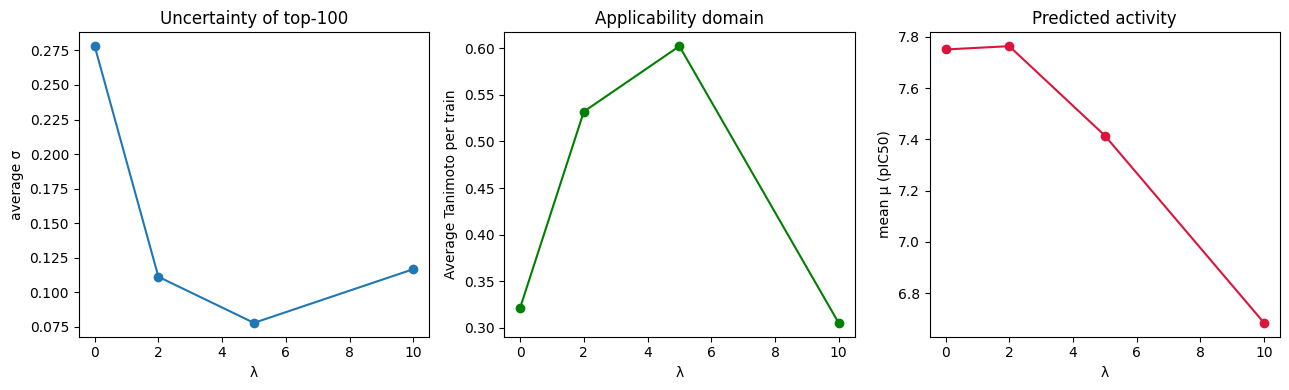

In [25]:
fig, ax = plt.subplots(1, 3, figsize=(13, 4))
ax[0].plot(abl["lambda"], abl["mean_sigma"], "-o")
ax[0].set_title("Uncertainty of top-100"); ax[0].set_xlabel("λ"); ax[0].set_ylabel("average σ")
ax[1].plot(abl["lambda"], abl["mean_tanimoto"], "-o", color="green")
ax[1].set_title("Applicability domain"); ax[1].set_xlabel("λ"); ax[1].set_ylabel("Average Tanimoto per train")
ax[2].plot(abl["lambda"], abl["mean_mu"], "-o", color="crimson")
ax[2].set_title("Predicted activity"); ax[2].set_xlabel("λ"); ax[2].set_ylabel("mean μ (pIC50)")
plt.tight_layout(); plt.show()

In [26]:
d.sort_values("Score").head(5)["SMILES"]

754                  C=CC=NNC(=O)c1ccccc1N
8368           COC(=O)c1ccc(N)c(NC2CC2C)c1
8321          Cn1cccc1CNCC1(C2CCCC2)CCNCC1
8333    Cc1ccc(-c2ccc(CC(=O)O)n2C2CC2)cc1C
2969        Cc1cccc(C(O)CN2CCCC(C)CC2=O)c1
Name: SMILES, dtype: object

In [27]:
lambdas, seeds = [0, 2, 5, 10], [0, 1, 2]
records = []
for L in lambdas:
    for S in seeds:
        d = pd.read_csv(f"{REPO}/rl_runs/egfr_pessimism_seeds/egfr_pess_l{L}_s{S}_1.csv")
        top = d.sort_values("Score", ascending=False)["SMILES"].drop_duplicates().head(100).tolist()
        mus, sigs = zip(*[predict_mu_sigma(s) for s in top])
        records.append(dict(lam=L, seed=S,
            mu=np.nanmean(mus), sigma=np.nanmean(sigs),
            tani=np.nanmean([max_tani(s) for s in top]),
            qed=np.nanmean([QED.qed(m) if (m := Chem.MolFromSmiles(s)) else np.nan for s in top])))
R = pd.DataFrame(records)
print(R.groupby("lam").agg(["mean", "std"]).round(3))

    seed          mu         sigma          tani           qed       
    mean  std   mean    std   mean    std   mean    std   mean    std
lam                                                                  
0    1.0  1.0  7.725  0.048  0.216  0.012  0.355  0.010  0.205  0.036
2    1.0  1.0  7.850  0.137  0.115  0.012  0.488  0.019  0.327  0.040
5    1.0  1.0  7.303  0.100  0.102  0.020  0.490  0.070  0.435  0.112
10   1.0  1.0  6.622  0.065  0.112  0.004  0.300  0.018  0.474  0.012


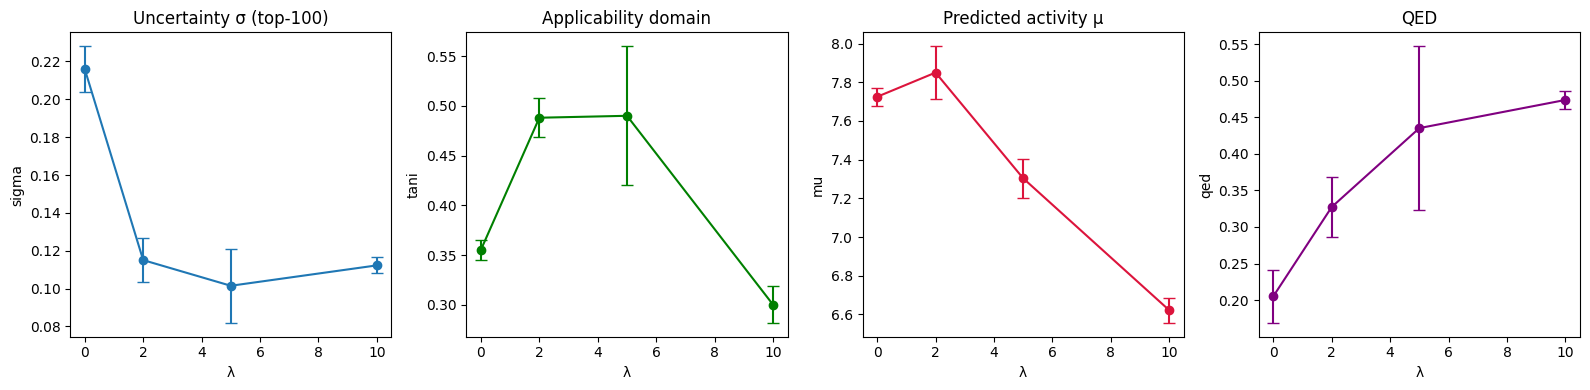

In [28]:
g = R.groupby("lam")
fig, ax = plt.subplots(1, 4, figsize=(16, 4))
for a, col, title, c in [(ax[0], "sigma", "Uncertainty σ (top-100)", "tab:blue"),
                         (ax[1], "tani", "Applicability domain", "green"),
                         (ax[2], "mu", "Predicted activity μ", "crimson"),
                         (ax[3], "qed", "QED", "purple")]:
    m, s = g[col].mean(), g[col].std()
    a.errorbar(m.index, m.values, yerr=s.values, marker="o", capsize=4, color=c)
    a.set_xlabel("λ"); a.set_ylabel(col); a.set_title(title)
plt.tight_layout(); plt.show()

Across three seeds, the four panels trace a consistent picture as λ increases from 0 to 10. The uncertainty of the top-100 molecules drops sharply from 0.216 ± 0.012 at λ = 0 to 0.115 ± 0.012 at λ = 2, then plateaus (0.102 ± 0.020 at λ = 5, 0.112 ± 0.004 at λ = 10). Applicability-domain similarity rises from 0.355 ± 0.010 to a plateau around 0.49 (0.488 ± 0.019 at λ = 2 and 0.490 ± 0.070 at λ = 5, indistinguishable within error), before collapsing to 0.300 ± 0.018 at λ = 10. Predicted activity is essentially flat up to λ = 2 (7.73 → 7.85) and then declines steadily to 6.62 ± 0.065 at λ = 10. QED increases monotonically over the whole range, from 0.205 ± 0.036 to 0.474 ± 0.012.
The curves describe the exploitation/reliability trade-off that pessimism is meant to create. Almost all of the reliability gain is reached by λ = 2: σ has already dropped and the domain similarity has already risen, while activity is untouched. This is the useful regime, where the agent is pulled back in-domain at no cost in predicted pIC50. Larger λ is counterproductive. Activity falls, and at λ = 10 the agent overshoots and drifts out of the domain again, most likely because minimising σ on its own rewards confidently predicted but low-activity regions rather than the active chemistry. The wide error bar on the domain metric at λ = 5 is itself informative: a single run had swung between 0.27 and 0.60, which is why the ablation is averaged over seeds rather than read from one run. The steadily rising QED, a quantity the reward never sees, is an early hint that the effect is more than a mechanical reduction of σ.

In [29]:
def load_top(L, k=100):
    smis = []
    for S in [0, 1, 2]:
        d = pd.read_csv(f"{REPO}/rl_runs/egfr_pessimism_seeds/egfr_pess_l{L}_s{S}_1.csv")
        smis += d.sort_values("Score", ascending=False)["SMILES"].drop_duplicates().head(k).tolist()
    return smis

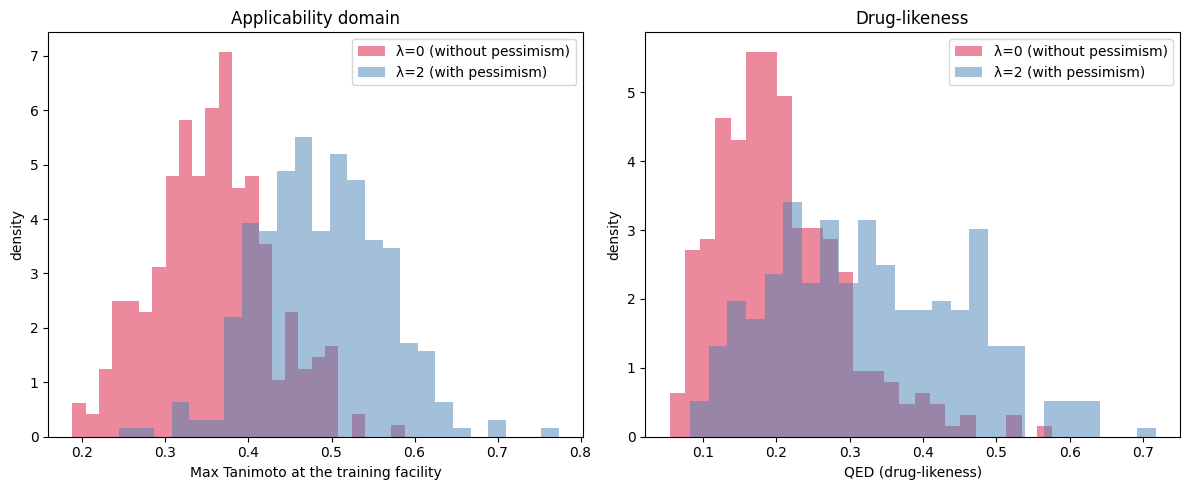

In [30]:
from rdkit.Chem import QED
top0, top2 = load_top(0), load_top(2)

tani0 = np.array([max_tani(s) for s in top0]); tani2 = np.array([max_tani(s) for s in top2])
qed0  = np.array([QED.qed(m) if (m := Chem.MolFromSmiles(s)) else np.nan for s in top0])
qed2  = np.array([QED.qed(m) if (m := Chem.MolFromSmiles(s)) else np.nan for s in top2])

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].hist(tani0, bins=25, alpha=0.5, color="crimson",   density=True, label="λ=0 (without pessimism)")
ax[0].hist(tani2, bins=25, alpha=0.5, color="steelblue", density=True, label="λ=2 (with pessimism)")
ax[0].set_xlabel("Max Tanimoto at the training facility"); ax[0].set_ylabel("density")
ax[0].set_title("Applicability domain"); ax[0].legend()

ax[1].hist(qed0, bins=25, alpha=0.5, color="crimson",   density=True, label="λ=0 (without pessimism)")
ax[1].hist(qed2, bins=25, alpha=0.5, color="steelblue", density=True, label="λ=2 (with pessimism)")
ax[1].set_xlabel("QED (drug-likeness)"); ax[1].set_ylabel("density")
ax[1].set_title("Drug-likeness"); ax[1].legend()
plt.tight_layout(); plt.show()

Pooling the top-100 molecules of all three seeds, the distributions for the ordinary reward (λ = 0) and the pessimistic reward (λ = 2) are clearly displaced. The applicability-domain similarity moves from a distribution centred near 0.35 to one centred near 0.50, with far less mass below 0.3. The QED distribution shifts from a sharp peak around 0.15 to 0.20 toward a broader spread reaching 0.3 to 0.5. Neither Tanimoto to the training set nor QED is part of the reward.

This is the decisive evidence, precisely because it concerns quantities the reward does not optimise. The reduction in σ seen in the ablation is close to circular, since σ is exactly what R = μ − λσ penalises, so on its own it proves little. Here the agent was asked only to avoid uncertain predictions, yet its molecules ended up measurably closer to the training domain and more drug-like. The pessimistic reward therefore does not merely satisfy its own definition; it steers generation toward known, plausible chemistry as a side effect, which is the behaviour one wants from an uncertainty penalty. The remaining overlap between the two distributions is a reminder that the effect is a shift of the population, not a hard filter.

## Conclusion

Penalising the oracle's own uncertainty is enough to curb its exploitation. A pessimistic reward built from a bootstrap ensemble, R = μ − λσ, keeps the agent's best molecules inside the QSAR model's domain and makes them more drug-like, with an optimum around λ ≈ 2 where reliability improves at no cost in predicted activity. The improvement appears in metrics the reward does not optimise, so it is not an artefact of penalising σ. This is the same reward-hacking problem studied in reinforcement learning from human feedback, here with a rare advantage: the reward has a physical ground truth against which its honesty can, in principle, be checked.

## Perspectives

This notebook penalised the uncertainty of one reward term; the same logic extends to the whole objective, and it is the through-line for what follows: every predicted component added to the reward is a new surface the agent can exploit, so each should carry its own uncertainty rather than be trusted as a point estimate. The most immediate direction is selectivity. The hERG models of notebook 05 are already available, so the agent could maximise EGFR activity while minimising predicted hERG activity, turning the task into a realistic potency-versus-safety trade-off; both axes being predicted, their errors compound and the hERG term should receive the same pessimistic treatment. A cheap second addition is an aqueous-solubility term, which would tie this work back to the solubility models of notebooks 01 and 02. It should stay modest: solubility is already partly captured by QED and the physicochemical descriptors, so its marginal signal must be checked, and it is a developability proxy, not a study of drug delivery. A heavier step would constrain generation to a known scaffold, which REINVENT supports natively, moving the problem from de novo design toward lead optimisation and addressing the diversity behaviour seen earlier; this is a different objective rather than an extension of the same benchmark, and fixing the scaffold trades novelty for realism by design.